# XGBoost: predictive performance and fairness

Predict two-year recidivism (`Two_yr_Recidivism`) on the COMPAS cohort with XGBoost. Training lives in `xgb_model.py` (run it once to save the model to `models/`); the metrics live in `performance.py`. This notebook loads the saved model and shows the results.

- Shared stratified 70/30 train/test split (`compas_scoring.data.train_test`), so results are comparable with the other models.
- Hyperparameters picked by a randomized search with 5-fold CV on the **training set only**.
- The test set is used once, to report performance next to the incumbent COMPAS score.

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from performance import confusion, performance_table, roc_data, scores, load_xper
from xgb_model import load_data, load_metadata, load_model

## 1. Data

Feature set FS1 (`race_aware`): all 10 predictors. Change `FEATURE_SET` to `"selected"` (FS2) or `"race_blind"` (FS3) to rerun on the other sets.

In [4]:
FEATURE_SET = "race_aware"

train, test = load_data(FEATURE_SET)
print(f"{len(train)} train rows, {len(test)} test rows")
print(f"Recidivism rate - train: {train.base_rate:.3f}, test: {test.base_rate:.3f}")
train.X.head()

4320 train rows, 1852 test rows
Recidivism rate - train: 0.455, test: 0.455


,Number_of_Priors,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2. Saved model

Trained and tuned by `python xgboost/xgb_model.py`.

In [5]:
model = load_model(FEATURE_SET)
meta = load_metadata(FEATURE_SET)

print(f"Best CV AUC: {meta['cv_auc']:.4f}")
meta["best_params"]

Best CV AUC: 0.7245


{'subsample': 0.9,
 'reg_lambda': 1.0,
 'n_estimators': 100,
 'min_child_weight': 10,
 'max_depth': 4,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 1.0}

## 3. Predictive performance

Threshold 0.5. COMPAS is only available as a high/low label (`score_factor`), so its AUC and Brier score are those of a single cut-off.

In [6]:
performance_table(model, test)

,auc,accuracy,precision,recall,f1,brier
XGBoost,0.7329,0.6830,0.6834,0.5658,0.6191,0.2140
COMPAS (incumbent),0.6575,0.6614,0.6320,0.6133,0.6225,0.3386


In [7]:
confusion(model, test)

,predicted: no,predicted: yes
actual: no reoffence,788,221
actual: reoffence,366,477


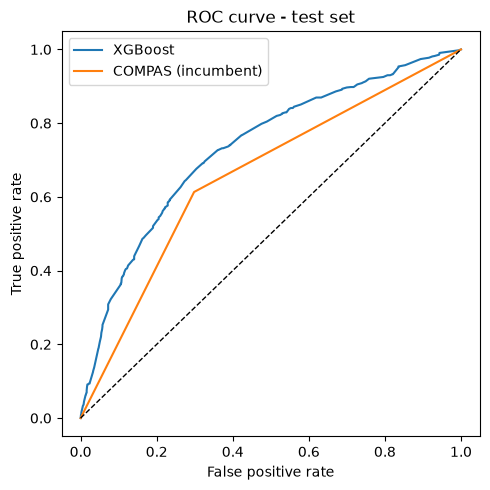

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, y_score in [("XGBoost", scores(model, test)), ("COMPAS (incumbent)", test.incumbent)]:
    roc = roc_data(test.y, y_score)
    ax.plot(roc.fpr, roc.tpr, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve - test set")
ax.legend()
plt.show()

In [ ]:
from XPER.viz.Visualisation import visualizationClass as viz

In [ ]:

phi, phi_i = load_xper(FEATURE_SET)
xper_test = test.subset(phi_i.index)  # the rows XPER was computed on

viz.bar_plot(
    XPER_values=(phi.to_numpy(), phi_i.to_numpy()),
    X_test=xper_test.X,
    labels=list(xper_test.X.columns),
    p=len(xper_test.X.columns),  
    percentage=True,
)

/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/python3.13/site-packages/XPER/viz/Visualisation.py:264: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_ind_i = benchmark_v_ind.iloc[ind_i][0]
/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/python3.13/site-packages/XPER/viz/Visualisation.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X=X[XPER > 0][index_sort_pos],
/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/p

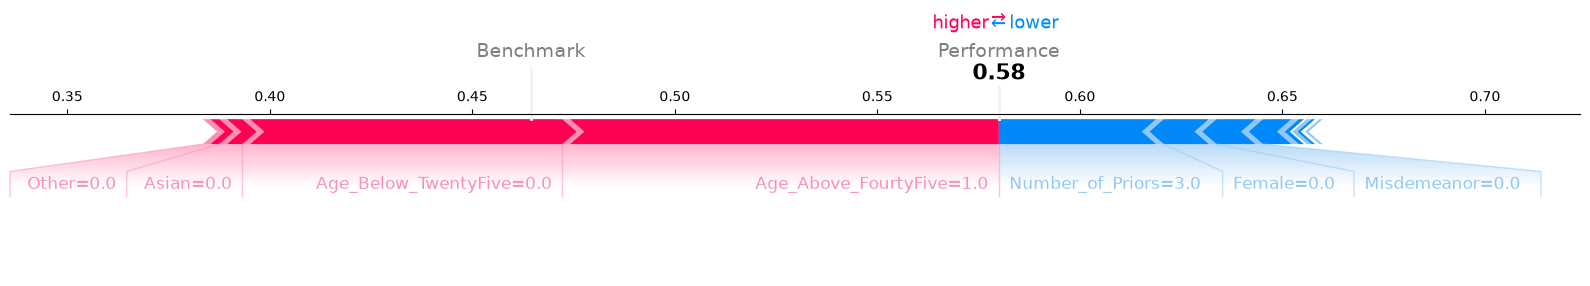

In [16]:
viz.force_plot(XPER_values=(phi.to_numpy(), phi_i.to_numpy()), 
               instance=5, 
               X_test=xper_test.X,
               variable_name=list(xper_test.X.columns), 
               figsize=(16,4))

## 4. Fairness

Method of Hurlin, Pérignon & Saurin, *The Fairness of Credit Scoring Models* (arXiv 2205.10200); code in `fairness.py`.

- **Statistical parity (SP)**: is the flag rate (predicted re-offence at threshold 0.5) independent of the group?
- **Conditional statistical parity (CSP)**: the same, within strata of legitimate risk factors: prior-offence band (0 / 1-3 / 4+) x charge degree.
- **Test**: the paper's likelihood-ratio test, one 2x2 table (prediction x group) per stratum, summed; chi2 with one degree of freedom per usable stratum. A stratum where one side is empty (e.g. nobody flagged) is dropped.
- The protected attribute must be binary, so each race group is compared with Caucasian defendants. Asian (n=11) and Native American (n=2) defendants are too few to test and are left out.
- Both models are compared: `race_aware` (race is an input) and `race_blind` (race removed, "fairness through unawareness").

In [17]:
import pandas as pd

from fairness import (
    candidate_variables,
    conditional_parity_detail,
    fpdp_all,
    group_rates,
    make_strata,
    parity_table,
    predict_labels,
)

FAIRNESS_MODELS = ["race_aware", "race_blind"]

fair = {}
for feature_set in FAIRNESS_MODELS:
    _, fs_test = load_data(feature_set)
    fs_model = load_model(feature_set)
    fair[feature_set] = {
        "test": fs_test,
        "model": fs_model,
        "y_pred": predict_labels(fs_model, fs_test),
        "strata": make_strata(fs_test),
    }

### 4.1 Flag rate vs actual re-offence rate

A gap in flag rates is only part of the story: the groups also differ in how often they actually re-offend (the base rate).

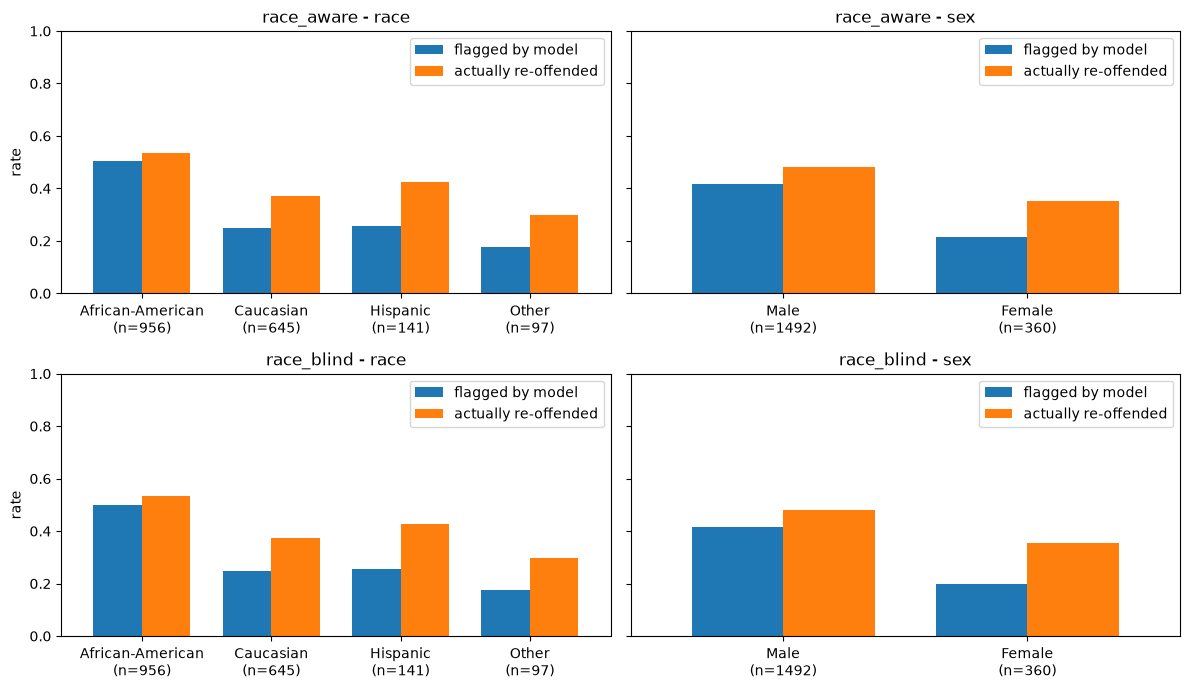

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for row, feature_set in enumerate(FAIRNESS_MODELS):
    f = fair[feature_set]
    for col, attribute in enumerate(["race", "sex"]):
        rates = group_rates(f["y_pred"], f["test"], attribute)
        ax = axes[row, col]
        rates[["flag_rate", "base_rate"]].plot.bar(ax=ax, rot=0, width=0.75)
        ax.set_xticklabels([f"{g}\n(n={n})" for g, n in rates["n"].items()])
        ax.set(title=f"{feature_set} - {attribute}", xlabel="", ylabel="rate", ylim=(0, 1))
        ax.legend(["flagged by model", "actually re-offended"], loc="upper right")
fig.tight_layout()
plt.show()

### 4.2 Statistical parity and conditional statistical parity tests

`sp_ratio` = flag rate of the protected group / flag rate of the reference group (1 = parity). p-values below 0.05 reject fairness.

In [19]:
columns = [
    "n_protected", "n_reference", "flag_rate_protected", "flag_rate_reference",
    "sp_difference", "sp_ratio", "sp_statistic", "sp_p_value",
    "csp_statistic", "csp_df", "csp_p_value",
]
parity = pd.concat(
    {fs: parity_table(fair[fs]["y_pred"], fair[fs]["test"], fair[fs]["strata"])[columns]
     for fs in FAIRNESS_MODELS},
    names=["model", "comparison"],
)
parity.astype(float).round(4)

n_protected  n_reference  \
model      comparison                                                
race_aware African-American vs Caucasian        956.0        645.0   
           Hispanic vs Caucasian                141.0        645.0   
           Other vs Caucasian                    97.0        645.0   
           Female vs Male                       360.0       1492.0   
race_blind African-American vs Caucasian        956.0        645.0   
           Hispanic vs Caucasian                141.0        645.0   
           Other vs Caucasian                    97.0        645.0   
           Female vs Male                       360.0       1492.0   

                                          flag_rate_protected  \
model      comparison                                           
race_aware African-American vs Caucasian               0.5063   
           Hispanic vs Caucasian                       0.2553   
           Other vs Caucasian                          0.1753   
           Female vs Male                              0.2167   
race_blind African-American vs Caucasian               0.5010   
           Hispanic vs Caucasian                       0.2553   
           Other vs Caucasian                          0.1753   
           Female vs Male                              0.2000   

                                          flag_rate_reference  sp_difference  \
model      comparison                                                          
race_aware African-American vs Caucasian               0.2496         0.2567   
           Hispanic vs Caucasian                       0.2496         0.0057   
           Other vs Caucasian                          0.2496        -0.0744   
           Female vs Male                              0.4155        -0.1989   
race_blind African-American vs Caucasian               0.2481         0.2530   
           Hispanic vs Caucasian                       0.2481         0.0073   
           Other vs Caucasian                          0.2481        -0.0728   
           Female vs Male                              0.4155        -0.2155   

                                          sp_ratio  sp_statistic  sp_p_value  \
model      comparison                                                          
race_aware African-American vs Caucasian    2.0282      108.6493      0.0000   
           Hispanic vs Caucasian            1.0229        0.0200      0.8875   
           Other vs Caucasian               0.7021        2.7152      0.0994   
           Female vs Male                   0.5214       52.0816      0.0000   
race_blind African-American vs Caucasian    2.0198      105.8969      0.0000   
           Hispanic vs Caucasian            1.0293        0.0324      0.8571   
           Other vs Caucasian               0.7065        2.6109      0.1061   
           Female vs Male                   0.4813       61.9885      0.0000   

                                          csp_statistic  csp_df  csp_p_value  
model      comparison                                                         
race_aware African-American vs Caucasian        25.8599     4.0       0.0000  
           Hispanic vs Caucasian                 9.5304     4.0       0.0491  
           Other vs Caucasian                    2.0921     4.0       0.7188  
           Female vs Male                       28.5418     4.0       0.0000  
race_blind African-American vs Caucasian        24.4243     4.0       0.0001  
           Hispanic vs Caucasian                 9.9903     4.0       0.0406  
           Other vs Caucasian                    2.0760     4.0       0.7218  
           Female vs Male                       37.3946     4.0       0.0000

### 4.3 Conditional statistical parity by stratum

Where inside the strata does the gap come from? (`p_value` is NaN where the test is undefined: the model flags nobody in that stratum.)

In [20]:
for comparison in ["African-American vs Caucasian", "Female vs Male"]:
    f = fair["race_aware"]
    print(f"race_aware - {comparison}")
    display(conditional_parity_detail(f["y_pred"], f["test"], f["strata"], comparison).astype(float).round(4))

race_aware - African-American vs Caucasian


,n_protected,n_reference,flag_rate_protected,flag_rate_reference,statistic,p_value
0 priors | Felony,156.0,134.0,0.0000,0.0000,0.0000,NaN
0 priors | Misdemeanor,96.0,136.0,0.0000,0.0000,0.0000,NaN
1-3 priors | Felony,221.0,167.0,0.4796,0.3054,12.1467,0.0005
1-3 priors | Misdemeanor,109.0,92.0,0.2752,0.1304,6.5365,0.0106
4+ priors | Felony,279.0,82.0,0.9462,0.9024,1.8553,0.1732
4+ priors | Misdemeanor,95.0,34.0,0.8842,0.7059,5.3214,0.0211


race_aware - Female vs Male


,n_protected,n_reference,flag_rate_protected,flag_rate_reference,statistic,p_value
0 priors | Felony,75.0,275.0,0.0000,0.0000,0.0000,NaN
0 priors | Misdemeanor,92.0,210.0,0.0000,0.0000,0.0000,NaN
1-3 priors | Felony,80.0,357.0,0.2375,0.4258,10.2741,0.0013
1-3 priors | Misdemeanor,44.0,191.0,0.0455,0.2199,9.1280,0.0025
4+ priors | Felony,52.0,337.0,0.9038,0.9436,1.0894,0.2966
4+ priors | Misdemeanor,17.0,122.0,0.5882,0.8852,8.0502,0.0045


### 4.4 Fairness Partial Dependence Plots (FPDP)

Each panel sets one feature to the same value for **every** defendant, re-predicts, and plots the p-value of the statistical parity test (paper, Definitions 5-6). A feature is a **candidate variable** - a driver of the unfairness - if some value lifts the p-value above 5% (red line).

Hollow markers are **degenerate** values: the model then gives everyone the same prediction (flags nobody or everybody), so the test passes trivially. They are not counted as evidence.

Shown for the two comparisons with enough defendants for meaningful curves: African-American vs Caucasian and Female vs Male.

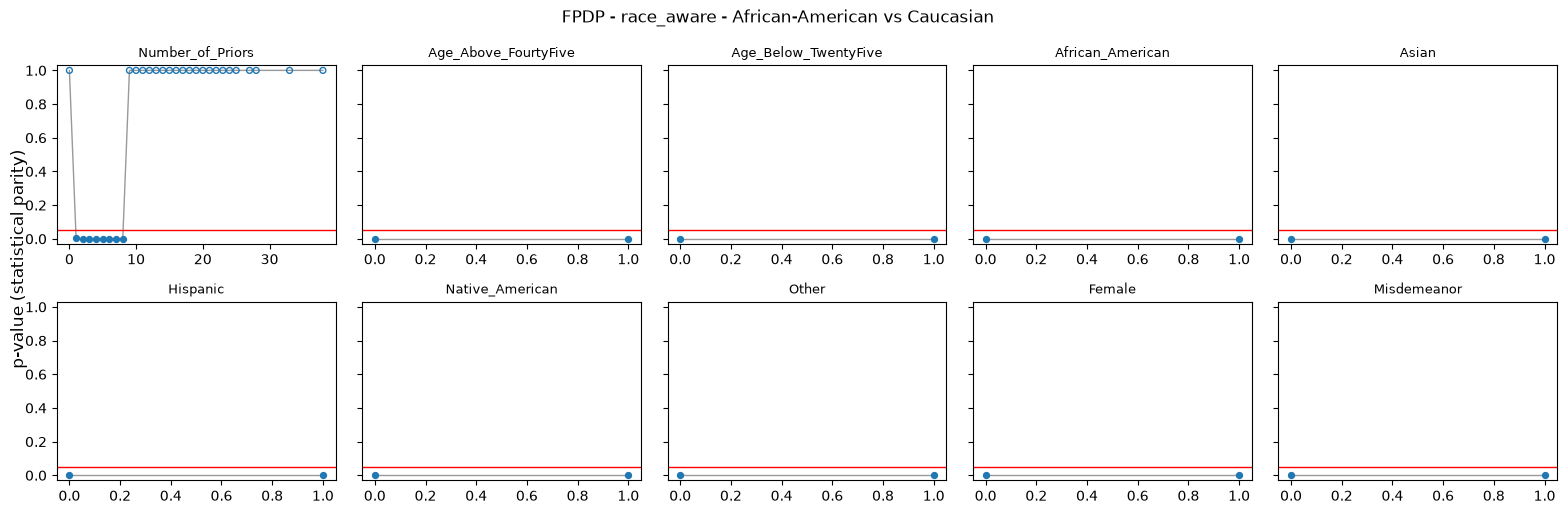

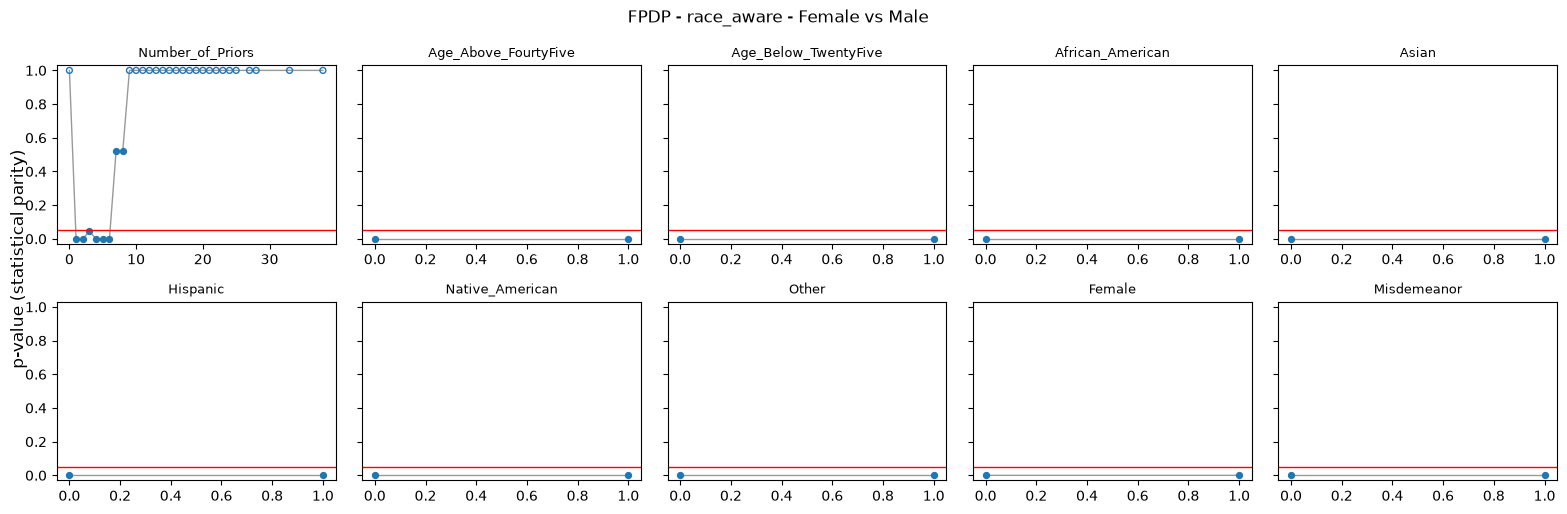

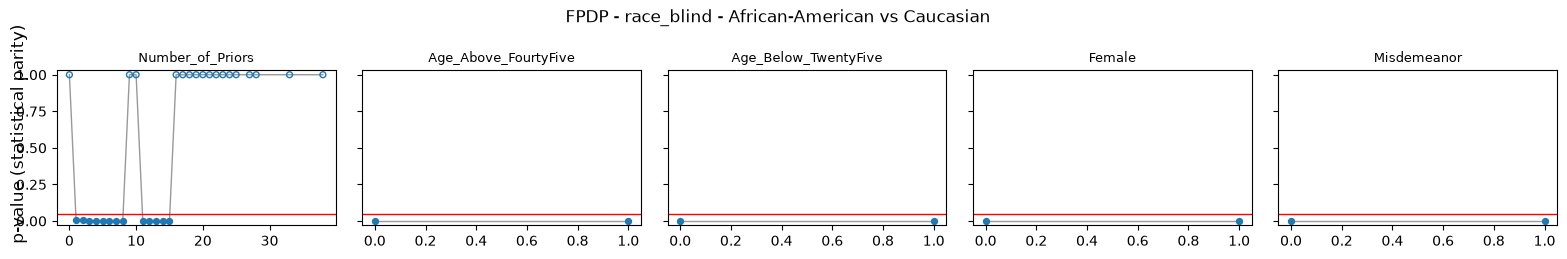

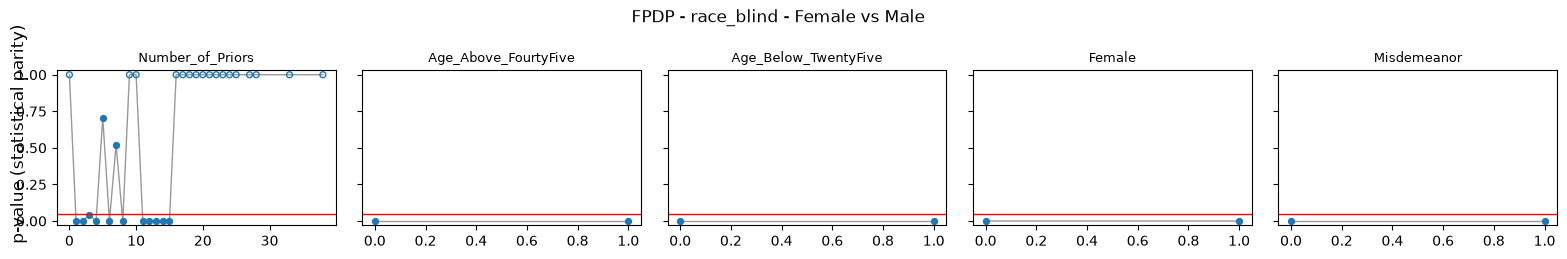

In [21]:
def plot_fpdp(curves, title, alpha=0.05):
    features = list(curves)
    ncols = 5
    nrows = -(-len(features) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharey=True, squeeze=False)
    for ax, feature in zip(axes.flat, features):
        curve = curves[feature]
        ax.plot(curve["value"], curve["p_value"], color="0.6", lw=1, zorder=1)
        real, degenerate = curve[~curve["degenerate"]], curve[curve["degenerate"]]
        ax.scatter(real["value"], real["p_value"], s=18, zorder=2)
        ax.scatter(degenerate["value"], degenerate["p_value"], s=18, facecolors="none", edgecolors="C0", zorder=2)
        ax.axhline(alpha, color="red", lw=1)
        ax.set_title(feature, fontsize=9)
        ax.set_ylim(-0.03, 1.03)
    for ax in axes.flat[len(features):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.supylabel("p-value (statistical parity)")
    fig.tight_layout()
    plt.show()


fpdp_results = {}
for feature_set in FAIRNESS_MODELS:
    f = fair[feature_set]
    for comparison in ["African-American vs Caucasian", "Female vs Male"]:
        curves = fpdp_all(f["model"], f["test"], comparison)
        fpdp_results[feature_set, comparison] = curves
        plot_fpdp(curves, f"FPDP - {feature_set} - {comparison}")

### 4.5 Candidate variables

Highest non-degenerate p-value reached by each feature, and the value at which it is reached.

In [22]:
pd.concat(
    {key: candidate_variables(curves) for key, curves in fpdp_results.items()},
    names=["model", "comparison", "feature"],
)

max_p_value  \
model      comparison                    feature                            
race_aware African-American vs Caucasian Number_of_Priors         0.00599   
                                         Age_Below_TwentyFive         0.0   
                                         Age_Above_FourtyFive         0.0   
                                         Misdemeanor                  0.0   
                                         African_American             0.0   
                                         Female                       0.0   
                                         Asian                        0.0   
                                         Hispanic                     0.0   
                                         Native_American              0.0   
                                         Other                        0.0   
           Female vs Male                Number_of_Priors        0.521401   
                                         Female                  0.000032   
                                         Age_Below_TwentyFive         0.0   
                                         Misdemeanor                  0.0   
                                         African_American             0.0   
                                         Asian                        0.0   
                                         Hispanic                     0.0   
                                         Native_American              0.0   
                                         Other                        0.0   
                                         Age_Above_FourtyFive         0.0   
race_blind African-American vs Caucasian Number_of_Priors         0.00599   
                                         Age_Below_TwentyFive         0.0   
                                         Age_Above_FourtyFive         0.0   
                                         Female                       0.0   
                                         Misdemeanor                  0.0   
           Female vs Male                Number_of_Priors        0.705557   
                                         Female                  0.000018   
                                         Age_Below_TwentyFive         0.0   
                                         Misdemeanor                  0.0   
                                         Age_Above_FourtyFive         0.0   

                                                              at_value  \
model      comparison                    feature                         
race_aware African-American vs Caucasian Number_of_Priors          1.0   
                                         Age_Below_TwentyFive      1.0   
                                         Age_Above_FourtyFive      1.0   
                                         Misdemeanor               0.0   
                                         African_American          0.0   
                                         Female                    0.0   
                                         Asian                     0.0   
                                         Hispanic                  0.0   
                                         Native_American           0.0   
                                         Other                     0.0   
           Female vs Male                Number_of_Priors          7.0   
                                         Female                    1.0   
                                         Age_Below_TwentyFive      0.0   
                                         Misdemeanor               0.0   
                                         African_American          1.0   
                                         Asian                     0.0   
                                         Hispanic                  0.0   
                                         Native_American           0.0   
                                         Other                     0.0   
                                         Ag

### 4.6 Is race recoverable from the race-blind features?

Section 4.2 showed that removing race from the model's inputs barely changes the disparity (`race_blind`'s ratio is 2.02, almost identical to `race_aware`'s 2.03). `race_proxy.py` asks why: instead of predicting recidivism, a fresh XGBoost model predicts **race** (African-American vs everyone else) from the race-blind features. If it can, "fairness through unawareness" was never going to work, because the model can still act on race indirectly, through whichever feature proxies for it.

In [ ]:
from race_proxy import race_proxy_table

race_proxy_table().round(4)

Both variants score well above the 0.5 no-information floor: race is recoverable from features that never mention it. `Number_of_Priors` alone accounts for most of that recoverability, consistent with it being the closest thing to a candidate variable in the FPDP above (section 4.4) - the other four features together add only a little more.